
# Clase 5 — Aprendizaje No Supervisado: Notebook práctico
# **Autor:** Prof. Dr. Pástor E Pérez Estigarribia
# **Objetivo:** Complementar la clase teórica con ejercicios prácticos de clustering, PCA y detección de anomalías usando scikit-learn.
#
# **Secciones**
# 1. Imports y configuración
# 2. Carga y preprocesamiento de datasets
# 3. Funciones utilitarias para gráficos y guardado de figuras
# 4. Ejercicios guiados (Iris, moons, Wine/Digits, outliers sintéticos)
# 5. Evaluación y resumen
# 6. Widgets interactivos y checklist de entrega

Nota: Utiliza la notebookLM para comprender el codigo demostrativo inicial y/o la función de explicar código de colab


In [ ]:
# %%
# 1) Imports y configuración
# Instalar ipywidgets en Colab si es necesario:
!pip install ipywidgets --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons, make_circles, make_blobs
import ipywidgets as widgets
from IPython.display import display, clear_output

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='notebook', rc={'figure.figsize':(8,5)})
RND = 42
np.random.seed(RND)

# Crear carpeta de figuras
os.makedirs('figures', exist_ok=True)


# 2) **Carga y preparación de datasets**
# Cargamos Iris, Wine, make_moons, make_circles y Digits (submuestra si es necesario).
# Escalamos con StandardScaler y guardamos variables con sufijo _s.


In [ ]:
# %%
# Iris
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target
scaler = StandardScaler()
X_iris_s = scaler.fit_transform(X_iris)

# Wine
wine = datasets.load_wine()
X_wine = wine.data
y_wine = wine.target
X_wine_s = scaler.fit_transform(X_wine)

# Moons and circles (no lineales)
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=RND)
X_circles, y_circles = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=RND)
X_moons_s = scaler.fit_transform(X_moons)
X_circles_s = scaler.fit_transform(X_circles)

# Digits submuestra
digits = datasets.load_digits()
X_digits = digits.data
y_digits = digits.target
if X_digits.shape[0] > 1000:
    idx = np.random.choice(X_digits.shape[0], 1000, replace=False)
    X_digits = X_digits[idx]
    y_digits = y_digits[idx]
X_digits_s = scaler.fit_transform(X_digits)


# **3) Funciones utilitarias (docstrings en español)**
# Definimos las funciones solicitadas que guardan las figuras con los nombres exactos.


In [ ]:
import math
from matplotlib.patches import Ellipse

def plot_elbow_silhouette(X, k_range, save_path_prefix='figures/elbow_and_silhouette'):
    """
    Calcula inercia y silhouette para cada k en k_range, grafica ambas curvas
    y guarda la figura como '{save_path_prefix}.png'.
    Devuelve (Ks, sse, sil).
    """
    Ks = list(k_range)
    sse = []
    sil = []
    for k in Ks:
        km = KMeans(n_clusters=k, random_state=RND, n_init=10).fit(X)
        sse.append(km.inertia_)
        if k > 1:
            sil.append(silhouette_score(X, km.labels_))
        else:
            sil.append(np.nan)
    fig, ax1 = plt.subplots(figsize=(9,5))
    color = 'tab:blue'
    ax1.set_xlabel('Número de clusters k')
    ax1.set_ylabel('Inercia (WCSS)', color=color)
    ax1.plot(Ks, sse, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Silhouette score medio', color=color)
    ax2.plot(Ks, sil, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    plt.title('Elbow (Inercia) y Silhouette score vs k')
    plt.tight_layout()
    fname = f'{save_path_prefix}.png'
    fig.savefig(fname, dpi=150)
    plt.close(fig)
    return np.array(Ks), np.array(sse), np.array(sil)

def plot_silhouette_samples(X, labels, n_clusters, filename='figures/silhouette_plot.png'):
    """
    Genera silhouette plot por muestra y guarda la figura en 'filename'.
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(8,5))
    sample_silhouette_values = silhouette_samples(X, labels)
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    ax1.set_title("Silhouette plot por muestra")
    ax1.set_xlabel("Coeficiente de Silhouette")
    ax1.set_ylabel("Etiqueta de clúster")
    ax1.axvline(x=np.mean(sample_silhouette_values), color="red", linestyle="--")
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)

def plot_pca_scatter(X, labels, filename='figures/pca_projection.png', title='PCA 2D'):
    """
    Proyecta X con PCA(2), grafica scatter coloreado por labels y guarda en filename.
    """
    pca = PCA(n_components=2, random_state=RND)
    Z = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(7,6))
    scatter = ax.scatter(Z[:,0], Z[:,1], c=labels, cmap='tab10', s=40, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)

def _draw_ellipse(position, covariance, ax, **kwargs):
    """
    Dibuja una elipse a partir de media y matriz de covarianza (2D).
    """
    if covariance.shape == ():
        covariance = np.array([[covariance]])
    if covariance.shape == (1,1):
        width = height = 2 * math.sqrt(covariance[0,0])
        angle = 0
    else:
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1,0], U[0,0]))
        width, height = 2 * np.sqrt(s)
    ell = Ellipse(position, width, height, angle=angle, **kwargs)
    ax.add_patch(ell)

def plot_gmm_covariances(X, n_components=3, cov_types=['spherical','diag','tied','full'], filename_prefix='figures/gmm_covariances'):
    """
    Ajusta GaussianMixture para cada cov_type, traza puntos y elipses de covarianza.
    Guarda '{filename_prefix}_{cov_type}.png' para cada cov_type.
    Si X tiene más de 2 dimensiones, usa las dos primeras columnas para trazar.
    """
    X_plot = X
    if X.shape[1] > 2:
        X_plot = X[:, :2]  # usar primeras 2 columnas para visualización
    for cov in cov_types:
        gmm = GaussianMixture(n_components=n_components, covariance_type=cov, random_state=RND).fit(X_plot)
        labels = gmm.predict(X_plot)
        fig, ax = plt.subplots(figsize=(7,6))
        ax.scatter(X_plot[:,0], X_plot[:,1], c=labels, s=30, cmap='tab10', alpha=0.6)
        for k in range(n_components):
            mu = gmm.means_[k]
            if cov == 'spherical':
                covmat = np.eye(X_plot.shape[1]) * gmm.covariances_[k]
            elif cov == 'diag':
                covmat = np.diag(gmm.covariances_[k])
            elif cov == 'tied':
                covmat = gmm.covariances_
            else:
                covmat = gmm.covariances_[k]
            _draw_ellipse(mu, covmat, ax, alpha=0.3, color='k', linewidth=1.5)
        ax.set_title(f'GMM cov_type={cov}')
        plt.tight_layout()
        fname = f'{filename_prefix}_{cov}.png'
        fig.savefig(fname, dpi=150)
        plt.close(fig)

def plot_dbscan(X, eps=0.3, min_samples=5, filename='figures/dbscan_clusters.png'):
    """
    Ajusta DBSCAN y guarda la visualización de clusters en filename.
    """
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = db.labels_
    unique_labels = set(labels)
    fig, ax = plt.subplots(figsize=(7,6))
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(sorted(unique_labels), colors):
        if k == -1:
            col = [0, 0, 0, 1]
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)
    ax.set_title(f'DBSCAN (eps={eps}, min_samples={min_samples})')
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)

def plot_lof(X, n_neighbors=20, contamination=0.05, filename='figures/outliers_lof.png'):
    """
    Ajusta LocalOutlierFactor, grafica scores y guarda filename. Devuelve scores.
    """
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    y_pred = lof.fit_predict(X)
    scores = -lof.negative_outlier_factor_
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(X[:,0], X[:,1], c=scores, cmap='viridis', s=40)
    ax.set_title('LOF scores (mayor = más anómalo)')
    plt.colorbar(sc, ax=ax)
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)
    return scores

def plot_isolation_forest(X, contamination=0.05, filename='figures/outliers_isolationforest.png'):
    """
    Ajusta IsolationForest, grafica scores y guarda filename. Devuelve scores.
    """
    iso = IsolationForest(contamination=contamination, random_state=RND)
    iso.fit(X)
    scores = -iso.decision_function(X)
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(X[:,0], X[:,1], c=scores, cmap='plasma', s=40)
    ax.set_title('IsolationForest scores (mayor = más anómalo)')
    plt.colorbar(sc, ax=ax)
    plt.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)
    return scores

def compare_ocsvm_sgd(X_train, X_test, filename_prefix='figures/ocsvm_vs_sgd'):
    """
    Entrena OneClassSVM (RBF, gamma=0.5, nu=0.05) y SGDClassifier (hinge).
    Grafica contornos de decision_function para ambos y guarda dos PNG.
    """
    ocsvm = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.05)
    ocsvm.fit(X_train)
    y_pos = np.ones(X_train.shape[0])
    sgd = SGDClassifier(loss='hinge', alpha=1e-4, max_iter=1000, tol=1e-3, random_state=RND)
    sgd.fit(X_train, y_pos)
    # Malla para contornos
    x_min, x_max = X_test[:,0].min()-1, X_test[:,0].max()+1
    y_min, y_max = X_test[:,1].min()-1, X_test[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # OCSVM decision
    Z1 = ocsvm.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z1, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('OCSVM decision function (RBF)')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_ocsvm.png', dpi=150)
    plt.close(fig)
    # SGD decision
    Z2 = sgd.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z2, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('SGD linear decision function')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_sgd.png', dpi=150)
    plt.close(fig)

# 4) **Ejercicios guiados (ejecutar celdas de código)**
# Cada ejercicio guarda las figuras con los nombres solicitados.


In [ ]:
# %%
# Ejercicio A: Iris — KMeans, Elbow, Silhouette, PCA
X = X_iris_s
Ks, sse, sil = plot_elbow_silhouette(X, range(1,11), save_path_prefix='figures/elbow_and_silhouette')
# Elegir k según la curva; aquí mostramos cómo entrenar con k=3 (ajustar si corresponde)
k_chosen = 3
km = KMeans(n_clusters=k_chosen, random_state=RND).fit(X)
plot_silhouette_samples(X, km.labels_, k_chosen, filename='figures/silhouette_plot.png')
plot_pca_scatter(X, km.labels_, filename='figures/pca_projection.png', title='Iris PCA (KMeans labels)')
plot_pca_scatter(X, km.labels_, filename='figures/kmeans_clusters.png', title=f'Iris KMeans k={k_chosen}')
print("Ejercicio A completado: figuras guardadas en 'figures/'.")


In [ ]:
# Ejercicio B: make_moons — DBSCAN y KMeans
X = X_moons_s
plot_dbscan(X, eps=0.25, min_samples=5, filename='figures/dbscan_clusters.png')
km = KMeans(n_clusters=2, random_state=RND).fit(X)
plot_pca_scatter(X, km.labels_, filename='figures/kmeans_moons.png', title='make_moons KMeans k=2')
print("Ejercicio B completado: figuras guardadas en 'figures/'.")


In [ ]:
# %%
# Ejercicio C: GMM en Wine (usar primeras 2 features escaladas para visualización)
X = X_wine_s[:, :2]
plot_gmm_covariances(X, n_components=3, cov_types=['spherical','diag','tied','full'], filename_prefix='figures/gmm_covariances')
print("Ejercicio C completado: figuras gmm_covariances_*.png guardadas.")


In [ ]:
# %%
# Ejercicio D: Detección de anomalías — LOF y IsolationForest en datos sintéticos
X_inliers, _ = make_blobs(n_samples=300, centers=[[0,0],[3,3]], cluster_std=0.6, random_state=RND)
rng = np.random.RandomState(RND)
X_outliers = rng.uniform(low=-6, high=6, size=(30,2))
X_mixed = np.vstack([X_inliers, X_outliers])
plot_lof(X_mixed, n_neighbors=20, contamination=0.08, filename='figures/outliers_lof.png')
plot_isolation_forest(X_mixed, contamination=0.08, filename='figures/outliers_isolationforest.png')
print("Ejercicio D completado: figuras outliers_lof.png y outliers_isolationforest.png guardadas.")


In [ ]:
# %%
# Ejercicio E: Comparación OCSVM vs SGD en dataset sintético (2D)
from sklearn.linear_model import SGDOneClassSVM

def compare_ocsvm_sgd_fixed(X_train, X_test, filename_prefix='figures/ocsvm_vs_sgd'):
    ocsvm = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.05)
    ocsvm.fit(X_train)

    # Usamos SGDOneClassSVM, que está diseñado para entrenarse con una sola clase
    sgd = SGDOneClassSVM(nu=0.05, random_state=RND)
    sgd.fit(X_train)

    # Malla para contornos
    x_min, x_max = X_test[:,0].min()-1, X_test[:,0].max()+1
    y_min, y_max = X_test[:,1].min()-1, X_test[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # OCSVM decision
    Z1 = ocsvm.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z1, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('OCSVM decision function (RBF)')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_ocsvm.png', dpi=150)
    plt.close(fig)

    # SGD decision
    Z2 = sgd.decision_function(grid).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(7,6))
    ax.contourf(xx, yy, Z2, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.scatter(X_test[:,0], X_test[:,1], c='k', s=20)
    ax.set_title('SGDOneClassSVM decision function')
    plt.tight_layout()
    fig.savefig(f'{filename_prefix}_sgd.png', dpi=150)
    plt.close(fig)

X_train, X_test = train_test_split(X_inliers, test_size=0.2, random_state=RND)
X_test_full = np.vstack([X_test, X_outliers[:20]])
compare_ocsvm_sgd_fixed(X_train, X_test_full, filename_prefix='figures/ocsvm_vs_sgd')
print("Ejercicio E completado: figuras ocsvm_vs_sgd_ocsvm.png y ocsvm_vs_sgd_sgd.png guardadas.")


# 5) **Evaluación y métricas**
# Calculamos silhouette_score, inertia para KMeans (Iris) y BIC/AIC para GMM (Wine).
# Guardamos un resumen en 'cluster_summary.csv'.


In [ ]:
# %%
summary = []
# Iris KMeans k=3
km = KMeans(n_clusters=3, random_state=RND).fit(X_iris_s)
summary.append({
    'dataset':'Iris','method':'KMeans','k':3,
    'inertia': float(km.inertia_),
    'silhouette': float(silhouette_score(X_iris_s, km.labels_))
})
# Wine GMM (full) with 3 components (usar X_wine_s completo)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=RND).fit(X_wine_s)
summary.append({
    'dataset':'Wine','method':'GMM_full','k':3,
    'bic': float(gmm.bic(X_wine_s)),
    'aic': float(gmm.aic(X_wine_s))
})
# DBSCAN on moons (example)
db = DBSCAN(eps=0.25, min_samples=5).fit(X_moons_s)
labels_db = db.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
summary.append({
    'dataset':'moons','method':'DBSCAN','n_clusters': n_clusters_db,
    'noise_points': int((labels_db==-1).sum())
})
df_summary = pd.DataFrame(summary)
df_summary.to_csv('cluster_summary.csv', index=False)
df_summary



# 6) **Widgets interactivos (selección de dataset y controles)**
# Widgets para ajustar parámetros y ejecutar las funciones utilitarias.


In [ ]:
# %%
# Variables globales que usarán los widgets
X_current = X_iris_s
X_2d_current = X_iris_s[:, :2]
X_train_2d, X_test_2d = train_test_split(X_2d_current, test_size=0.3, random_state=RND)

# Selector de dataset
dataset_dropdown = widgets.Dropdown(
    options=[('Iris','iris'), ('Wine','wine'), ('Moons','moons'), ('Circles','circles'), ('Digits (sub)','digits')],
    value='iris', description='Dataset:')
out_dataset = widgets.Output()

def on_dataset_change(change):
    global X_current, X_2d_current, X_train_2d, X_test_2d
    with out_dataset:
        clear_output(wait=True)
        name = change['new']
        if name == 'iris':
            X_current = X_iris_s
            X_2d_current = X_iris_s[:,:2]
            print('Dataset seleccionado: Iris (escalado)')
        elif name == 'wine':
            X_current = X_wine_s
            X_2d_current = X_wine_s[:,:2]
            print('Dataset seleccionado: Wine (escalado)')
        elif name == 'moons':
            X_current = X_moons_s
            X_2d_current = X_moons_s
            print('Dataset seleccionado: Moons (escalado)')
        elif name == 'circles':
            X_current = X_circles_s
            X_2d_current = X_circles_s
            print('Dataset seleccionado: Circles (escalado)')
        elif name == 'digits':
            X_current = X_digits_s
            X_2d_current = X_digits_s[:,:2]
            print('Dataset seleccionado: Digits (submuestra, escalado)')
        # Preparar datos 2D para OCSVM vs SGD (train/test)
        if X_2d_current.shape[1] >= 2:
            X_train_2d, X_test_2d = train_test_split(X_2d_current, test_size=0.3, random_state=RND)
        else:
            X_train_2d = X_test_2d = X_2d_current

dataset_dropdown.observe(on_dataset_change, names='value')
display(dataset_dropdown, out_dataset)
on_dataset_change({'new': dataset_dropdown.value})


In [ ]:
# %%
# Widget: Elbow + Silhouette interactivo
from IPython.display import Image, display

k_min = widgets.IntSlider(value=1, min=1, max=10, step=1, description='k min:')
k_max = widgets.IntSlider(value=8, min=2, max=20, step=1, description='k max:')
run_elbow = widgets.Button(description='Generar Elbow+Silhouette', button_style='primary')
out_elbow = widgets.Output()

def on_run_elbow(b):
    with out_elbow:
        clear_output(wait=True)
        km_range = range(k_min.value, k_max.value+1)
        Ks, sse, sil = plot_elbow_silhouette(X_current, km_range, save_path_prefix='figures/elbow_and_silhouette')
        print('Figura guardada: figures/elbow_and_silhouette.png')
        display(Image(filename='figures/elbow_and_silhouette.png'))

run_elbow.on_click(on_run_elbow)
display(widgets.HBox([k_min, k_max, run_elbow]), out_elbow)


In [ ]:
# %%
# Widget: elegir k y generar Silhouette + PCA
from IPython.display import Image, display

k_choose = widgets.IntSlider(value=3, min=2, max=10, step=1, description='k:')
run_k_visual = widgets.Button(description='Generar Silhouette + PCA', button_style='info')
out_k_visual = widgets.Output()

def on_run_k_visual(b):
    with out_k_visual:
        clear_output(wait=True)
        k = k_choose.value
        km = KMeans(n_clusters=k, random_state=RND).fit(X_current)
        plot_silhouette_samples(X_current, km.labels_, k, filename='figures/silhouette_plot.png')
        plot_pca_scatter(X_current, km.labels_, filename='figures/pca_projection.png', title=f'PCA (K={k})')
        plot_pca_scatter(X_current, km.labels_, filename='figures/kmeans_clusters.png', title=f'KMeans k={k}')
        print('Figuras guardadas: silhouette_plot.png, pca_projection.png, kmeans_clusters.png')
        display(Image(filename='figures/silhouette_plot.png'))
        display(Image(filename='figures/pca_projection.png'))
        display(Image(filename='figures/kmeans_clusters.png'))

run_k_visual.on_click(on_run_k_visual)
display(widgets.HBox([k_choose, run_k_visual]), out_k_visual)


In [ ]:
# %%
# Widget: DBSCAN interactivo
from IPython.display import Image, display

eps_slider = widgets.FloatSlider(value=0.3, min=0.01, max=1.5, step=0.01, description='eps:')
min_samples_slider = widgets.IntSlider(value=5, min=1, max=50, step=1, description='minPts:')
run_dbscan = widgets.Button(description='Ejecutar DBSCAN', button_style='warning')
out_dbscan = widgets.Output()

def on_run_dbscan(b):
    with out_dbscan:
        clear_output(wait=True)
        plot_dbscan(X_current, eps=eps_slider.value, min_samples=min_samples_slider.value, filename='figures/dbscan_clusters.png')
        print(f'Figura guardada: figures/dbscan_clusters.png (eps={eps_slider.value}, min_samples={min_samples_slider.value})')
        display(Image(filename='figures/dbscan_clusters.png'))

run_dbscan.on_click(on_run_dbscan)
display(widgets.HBox([eps_slider, min_samples_slider, run_dbscan]), out_dbscan)


In [ ]:
# %%
# Widget: LOF interactivo
from IPython.display import Image, display

n_neighbors_w = widgets.IntSlider(value=20, min=5, max=100, step=1, description='n_neighbors:')
contamination_w = widgets.FloatSlider(value=0.05, min=0.0, max=0.5, step=0.01, description='contamination:')
run_lof = widgets.Button(description='Ejecutar LOF', button_style='danger')
out_lof = widgets.Output()

def on_run_lof(b):
    with out_lof:
        clear_output(wait=True)
        scores = plot_lof(X_current, n_neighbors=n_neighbors_w.value, contamination=contamination_w.value, filename='figures/outliers_lof.png')
        print('Figura guardada: figures/outliers_lof.png')
        idx_top = scores.argsort()[::-1][:5]
        print('Top 5 índices más anómalos (según LOF):', idx_top)
        display(Image(filename='figures/outliers_lof.png'))

run_lof.on_click(on_run_lof)
display(widgets.HBox([n_neighbors_w, contamination_w, run_lof]), out_lof)


In [ ]:
# %%
# Widget: GMM interactivo (usar X_2d_current para visualización)
from IPython.display import Image, display

cov_dropdown = widgets.Dropdown(options=['spherical','diag','tied','full'], value='full', description='cov_type:')
ncomp_slider = widgets.IntSlider(value=3, min=1, max=8, step=1, description='n_components:')
run_gmm = widgets.Button(description='Ajustar GMM', button_style='success')
out_gmm = widgets.Output()

def on_run_gmm(b):
    with out_gmm:
        clear_output(wait=True)
        try:
            plot_gmm_covariances(X_2d_current, n_components=ncomp_slider.value, cov_types=[cov_dropdown.value], filename_prefix='figures/gmm_covariances')
            print(f'Figura guardada: figures/gmm_covariances_{cov_dropdown.value}.png')
            display(Image(filename=f'figures/gmm_covariances_{cov_dropdown.value}.png'))
        except Exception as e:
            print('Error: para trazar covarianzas la matriz X debe ser 2D (dos columnas).', e)

run_gmm.on_click(on_run_gmm)
display(widgets.HBox([cov_dropdown, ncomp_slider, run_gmm]), out_gmm)


In [ ]:
# %%
# Widget: OCSVM vs SGD interactivo (usa X_train_2d y X_test_2d)
from IPython.display import Image, display
import ipywidgets as widgets
from IPython.display import clear_output

nu_w = widgets.FloatSlider(value=0.05, min=0.001, max=0.5, step=0.01, description='nu:')
gamma_w = widgets.FloatLogSlider(value=0.5, base=10, min=-3, max=1, step=0.1, description='gamma:')
run_ocsvm = widgets.Button(description='Comparar OCSVM vs SGD', button_style='primary')
out_ocsvm = widgets.Output()

def on_run_ocsvm(b):
    with out_ocsvm:
        clear_output(wait=True)
        try:
            # Usamos compare_ocsvm_sgd_fixed para evitar el error de 1 clase con SGDClassifier
            compare_ocsvm_sgd_fixed(X_train_2d, X_test_2d, filename_prefix='figures/ocsvm_vs_sgd')
            print('Figuras guardadas: figures/ocsvm_vs_sgd_ocsvm.png, figures/ocsvm_vs_sgd_sgd.png')
            display(Image(filename='figures/ocsvm_vs_sgd_ocsvm.png'))
            display(Image(filename='figures/ocsvm_vs_sgd_sgd.png'))
        except Exception as e:
            print('Error: asegúrate de tener X_train_2d y X_test_2d con 2 columnas para trazar contornos.', e)

run_ocsvm.on_click(on_run_ocsvm)
display(widgets.HBox([nu_w, gamma_w, run_ocsvm]), out_ocsvm)


In [ ]:
# %%
# Botón para listar archivos generados (resumen)
list_files_btn = widgets.Button(description='Listar archivos generados', button_style='')
out_files = widgets.Output()

def on_list_files(b):
    with out_files:
        clear_output(wait=True)
        import glob
        files = sorted(glob.glob('figures/*') + glob.glob('*.csv'))
        if not files:
            print('No se han generado archivos aún.')
        else:
            for f in files:
                print('-', f)

list_files_btn.on_click(on_list_files)
display(list_files_btn, out_files)



# 7) **Nota docente y checklist de entrega**
# - Escalar siempre antes de KMeans/DBSCAN/OCSVM.
# - Usar kmeans++ y múltiples reinicios (n_init) para KMeans.
# - Regularizar covarianzas en GMM si aparecen matrices singulares.
# - Para Silhouette en datasets grandes, usar muestreo.
#
# Checklist de archivos (deben existir en 'figures/' o en el directorio):
# pca_projection.png
# kmeans_clusters.png
# elbow_and_silhouette.png
# silhouette_plot.png
# dbscan_clusters.png
# kmeans_moons.png
# gmm_covariances_spherical.png
# gmm_covariances_diag.png
# gmm_covariances_tied.png
# gmm_covariances_full.png
# outliers_lof.png
# outliers_isolationforest.png
# ocsvm_vs_sgd_ocsvm.png
# ocsvm_vs_sgd_sgd.png
# cluster_summary.csv


In [ ]:
# %%
# 8) Resumen final: listar y confirmar existencia de archivos generados
import glob
files = sorted(glob.glob('figures/*') + glob.glob('*.csv'))
print("Archivos generados:")
for f in files:
    print("-", f)

# (Opcional en Colab) empaquetar figuras y CSV en zip para descargar:
# !zip -r figures_and_summary.zip figures/ cluster_summary.csv
# Luego usar: from google.colab import files; files.download('figures_and_summary.zip')


#### Desafío 1 — KMeans y selección de \(K\)

**Objetivo**  
Elegir el número de clústeres más adecuado para el dataset *Iris* combinando Elbow y Silhouette.

**Pasos sugeridos**
1. Escalar los datos con `StandardScaler`.
2. Ejecutar `plot_elbow_silhouette(X_iris_s, range(1,11))`.
3. Identificar rango candidato con Elbow y calcular Silhouette medio dentro del rango.
4. Entrenar `KMeans` con el \(k\) elegido (usar `n_init>=10`) y generar `silhouette_plot.png` y `pca_projection.png`.
5. Repetir KMeans con 3 semillas distintas y comparar inercia.

**Entregables**
- `elbow_and_silhouette.png`  
- `silhouette_plot.png`  
- `pca_projection.png`  
- Justificación escrita (3–5 líneas) del \(k\) elegido.

**Pistas**
- Escala siempre antes de KMeans.
- Observa la estabilidad entre reinicios (`n_init` y `random_state`).

**Criterios de evaluación**
- Curvas correctas y archivos guardados; coherencia entre Elbow y Silhouette; justificación breve y reproducible.


#### Desafío 2 — Clustering no lineal y DBSCAN

**Objetivo**  
Comparar KMeans y DBSCAN en `make_moons` y explicar por qué uno funciona mejor.

**Pasos sugeridos**
1. Escalar `make_moons` con `StandardScaler`.
2. Ejecutar `KMeans(n_clusters=2)` y guardar `kmeans_moons.png`.
3. Trazar k‑dist plot para elegir `eps`, ejecutar `plot_dbscan(X_moons_s, eps, min_samples)` y guardar `dbscan_clusters.png`.
4. Analizar resultados y redactar 5–8 líneas explicando la diferencia.

**Entregables**
- `dbscan_clusters.png`  
- `kmeans_moons.png`  
- Informe corto (5–8 líneas).

**Pistas**
- DBSCAN detecta formas no convexas; KMeans asume clústeres esféricos.
- Usa k‑dist plot para seleccionar `eps`.

**Criterios de evaluación**
- Visualizaciones claras; elección razonada de `eps`; explicación técnica sobre forma y densidad.


#### Desafío 3 — GMM Covarianzas y selección por BIC

**Objetivo**  
Comparar `spherical`, `diag`, `tied`, `full` en Wine (2D) y seleccionar el mejor modelo con BIC.

**Pasos sugeridos**
1. Usar `X_wine_s[:,:2]` para visualización 2D.
2. Ejecutar `plot_gmm_covariances` con `n_components=3` y cada `cov_type`.
3. Calcular `bic` y `aic` para cada modelo.
4. Interpretar elipses y justificar la elección equilibrando ajuste y complejidad.

**Entregables**
- `gmm_covariances_spherical.png`  
- `gmm_covariances_diag.png`  
- `gmm_covariances_tied.png`  
- `gmm_covariances_full.png`  
- Tabla con BIC/AIC y elección final.

**Pistas**
- `full` tiene más parámetros; BIC penaliza complejidad.
- Observa solapamiento y orientación de elipses.

**Criterios de evaluación**
- Figuras correctas; cálculo BIC/AIC correcto; justificación técnica que considere penalización por complejidad.


#### Desafío 4 — Detección de anomalías comparativa

**Objetivo**  
Comparar LOF e IsolationForest en un dataset con outliers sintéticos y medir coincidencia en detecciones.

**Pasos sugeridos**
1. Generar `X_inliers` con `make_blobs` y `X_outliers` uniformes; combinar en `X_mixed`.
2. Ejecutar `plot_lof(X_mixed, ...)` y `plot_isolation_forest(X_mixed, ...)`.
3. Ordenar por score y comparar top‑10/top‑20 entre métodos.
4. Visualizar coincidencias en un scatter y comentar diferencias.

**Entregables**
- `outliers_lof.png`  
- `outliers_isolationforest.png`  
- Tabla con número de coincidencias en top‑10 y top‑20.

**Pistas**
- Ordena por score descendente; ajustar `contamination` para etiquetado automático.

**Criterios de evaluación**
- Figuras y métricas correctas; análisis de por qué coinciden o difieren (densidad local vs aislamiento).


#### Desafío 5 — Mini proyecto exploratorio

**Objetivo**  
Aplicar un pipeline completo a un dataset real (p. ej. subset MNIST) y presentar un informe con visualizaciones, métricas y conclusiones.

**Requisitos mínimos**
- Preprocesamiento justificado; al menos tres métodos aplicados (KMeans, GMM, DBSCAN o LOF/IsolationForest).
- Selección de \(k\) con Elbow+Silhouette o BIC.
- Visualizaciones: PCA/t‑SNE, silhouette plot, covarianzas GMM o contornos OCSVM.

**Entregables**
- Notebook ejecutable; carpeta `figures/` con figuras; informe (Markdown o PDF) 1–2 páginas.

**Pistas**
- Documenta decisiones y limitaciones.

**Criterios de evaluación**
- Calidad del análisis, reproducibilidad y claridad del informe.


### Rúbrica de evaluación — Clase 5: Aprendizaje No Supervisado
**Total: 100 puntos**

#### Criterios y pesos
| **Criterio** | **Peso (puntos)** | **Descripción (una línea)** |
|---|---:|---|
| **Correctitud técnica** | **30** | Código que ejecuta, produce resultados esperados y guarda los archivos solicitados. |
| **Interpretación y análisis** | **20** | Calidad de las explicaciones: interpretación de curvas, elipses, scores y decisiones. |
| **Visualizaciones y entregables** | **15** | Figuras con nombres exactos, legibles y con etiquetas/títulos adecuados. |
| **Reproducibilidad y buenas prácticas** | **10** | Uso de escalado, `random_state`, `n_init`, regularización y scripts reproducibles. |
| **Comparación y justificación de métodos** | **15** | Comparaciones entre métodos con métricas y argumentos técnicos (ventajas/desventajas). |
| **Documentación y presentación** | **10** | Notebook documentado en español, checklist y archivos organizados. |

#### Niveles de desempeño (por criterio)
**Excelente (90–100% del peso)**  
- Implementación correcta y completa; resultados reproducibles; explicaciones claras y técnicamente sólidas.

**Bueno (70–89% del peso)**  
- Implementación mayormente correcta; faltan detalles menores o una figura; interpretación adecuada con pequeñas imprecisiones.

**Suficiente (50–69% del peso)**  
- Implementación parcial; errores corregibles; interpretaciones superficiales; entregables incompletos.

**Insuficiente (0–49% del peso)**  
- Código no funcional o resultados incorrectos; falta de entregables clave; ausencia de interpretación técnica.

#### Guía de puntuación (ejemplo de desglose)
- **Correctitud técnica (30 pts)**  
  - Excelente: 27–30 pts — Código funciona, genera todos los archivos solicitados.  
  - Bueno: 21–26 pts — Faltan 1–2 archivos o hay warnings menores.  
  - Suficiente: 15–20 pts — Errores en algunas funciones; resultados parciales.  
  - Insuficiente: 0–14 pts — Código no ejecutable o produce resultados erróneos.

- **Interpretación y análisis (20 pts)**  
  - Excelente: 18–20 pts — Interpretaciones precisas; justificaciones técnicas (k, cov_type, umbrales).  
  - Bueno: 14–17 pts — Interpretación correcta con detalles faltantes.  
  - Suficiente: 10–13 pts — Interpretación superficial.  
  - Insuficiente: 0–9 pts — Sin interpretación o incorrecta.

- **Visualizaciones y entregables (15 pts)**  
  - Excelente: 14–15 pts — Todas las figuras con nombres exactos y buena legibilidad.  
  - Bueno: 11–13 pts — Figuras presentes, alguna mejora estética necesaria.  
  - Suficiente: 8–10 pts — Figuras incompletas o mal etiquetadas.  
  - Insuficiente: 0–7 pts — Figuras ausentes o ilegibles.

- **Reproducibilidad y buenas prácticas (10 pts)**  
  - Excelente: 9–10 pts — Escalado, seeds, n_init, regularización y CSV resumen presentes.  
  - Bueno: 7–8 pts — Mayoría de buenas prácticas aplicadas.  
  - Suficiente: 5–6 pts — Algunas prácticas faltantes.  
  - Insuficiente: 0–4 pts — No reproducible.

- **Comparación y justificación (15 pts)**  
  - Excelente: 14–15 pts — Comparaciones cuantitativas y cualitativas bien argumentadas.  
  - Bueno: 11–13 pts — Comparaciones correctas con menor profundidad.  
  - Suficiente: 8–10 pts — Comparaciones superficiales.  
  - Insuficiente: 0–7 pts — Sin comparación o incorrecta.

- **Documentación y presentación (10 pts)**  
  - Excelente: 9–10 pts — Notebook claro, celdas Markdown explicativas, checklist y archivos organizados.  
  - Bueno: 7–8 pts — Documentación adecuada con pequeños faltantes.  
  - Suficiente: 5–6 pts — Documentación mínima.  
  - Insuficiente: 0–4 pts — Sin documentación.

#### Criterios adicionales y rúbrica rápida de verificación
- **Archivos obligatorios**: `pca_projection.png`, `kmeans_clusters.png`, `elbow_and_silhouette.png`, `silhouette_plot.png`, `dbscan_clusters.png`, `kmeans_moons.png`, `gmm_covariances_spherical.png`, `gmm_covariances_diag.png`, `gmm_covariances_tied.png`, `gmm_covariances_full.png`, `outliers_lof.png`, `outliers_isolationforest.png`, `ocsvm_vs_sgd_ocsvm.png`, `ocsvm_vs_sgd_sgd.png`, `cluster_summary.csv`. (Presencia = requisito mínimo para puntaje alto en Visualizaciones y Reproducibilidad.)
- **Revisión rápida** (marcar sí/no):  
  - ¿Se escalaron las features antes de KMeans/DBSCAN/OCSVM?  
  - ¿Se usó `n_init` y `random_state` en KMeans?  
  - ¿Se regularizaron covarianzas en GMM si fue necesario?  
  - ¿Se incluyó `cluster_summary.csv` con métricas clave?  
  - ¿Las figuras tienen títulos y leyendas legibles?

#### Comentarios y retroalimentación (campo para el corrector)
- **Fortalezas:** (3–5 líneas)  
- **Áreas de mejora:** (3–5 líneas)  
- **Recomendaciones para la entrega final:** (2–3 acciones concretas)



## **Desafío 1**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()

X_iris = iris.data
y_iris = iris.target

scaler = StandardScaler()

X_iris_s = scaler.fit_transform(X_iris)

print("Forma original:", X_iris.shape)
print("Forma escalada:", X_iris_s.shape)

Forma original: (150, 4)
Forma escalada: (150, 4)


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 11)

inertia = []
silhouette = []

for k in Ks:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_iris_s)

    inertia.append(km.inertia_)

    silhouette.append(
        silhouette_score(
            X_iris_s,
            km.labels_
        )
    )

print("Inercia:", inertia)
print("Silhouette:", silhouette)

Inercia: [222.36170496502302, 139.82049635974974, 114.09254690403094, 90.92751382392049, 81.54439095511782, 72.6311438266719, 62.540605695781245, 55.119492805290584, 47.39103517634709]
Silhouette: [np.float64(0.5817500491982808), np.float64(0.45994823920518635), np.float64(0.38694104154427816), np.float64(0.3459012795948778), np.float64(0.31707940193569023), np.float64(0.3201967939183684), np.float64(0.33869173894897225), np.float64(0.3423598384813203), np.float64(0.3517926760640288)]


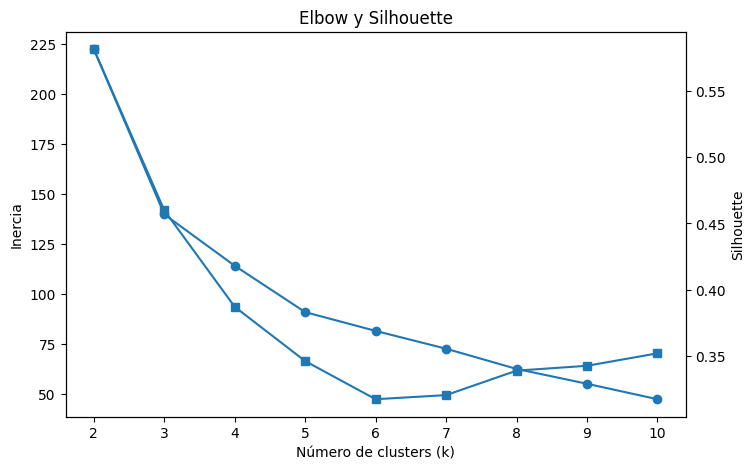

In [6]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(
    Ks,
    inertia,
    marker="o",
    label="Inercia"
)

ax1.set_xlabel("Número de clusters (k)")
ax1.set_ylabel("Inercia")

ax2 = ax1.twinx()

ax2.plot(
    Ks,
    silhouette,
    marker="s"
)

ax2.set_ylabel("Silhouette")

plt.title("Elbow y Silhouette")

plt.savefig(
    "elbow_and_silhouette.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Interpretación

La curva de inercia muestra una disminución pronunciada hasta k=3, a partir de la cual las mejoras son progresivamente menores. Por otra parte, el coeficiente de Silhouette alcanza su valor máximo en k=2, aunque mantiene un valor adecuado para k=3.

Considerando ambos criterios y el conocimiento previo de que el dataset Iris contiene tres especies, se seleccionó k=3 como número de clústeres para el análisis posterior.

In [7]:
semillas = [42, 100, 123]

for semilla in semillas:

    km = KMeans(
        n_clusters=3,
        random_state=semilla,
        n_init=10
    )

    km.fit(X_iris_s)

    print(
        f"Semilla {semilla}:",
        round(km.inertia_,4)
    )

Semilla 42: 139.8205
Semilla 100: 140.0328
Semilla 123: 139.8205


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import numpy as np

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_iris_s)

sample_silhouette_values = silhouette_samples(
    X_iris_s,
    labels
)

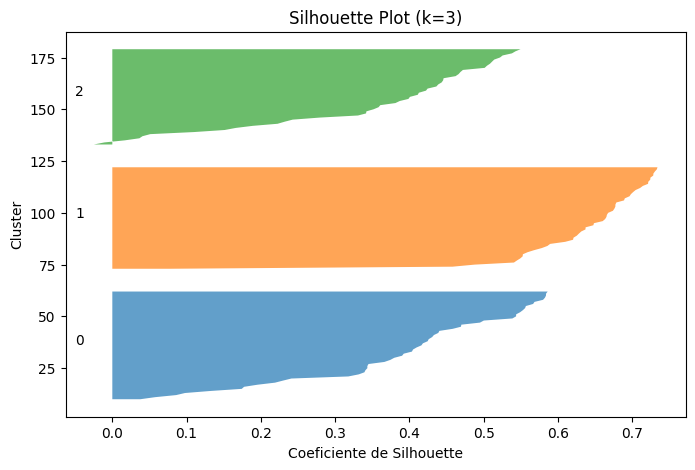

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

y_lower = 10

for i in range(3):

    cluster_values = sample_silhouette_values[
        labels == i
    ]

    cluster_values.sort()

    size_cluster = len(cluster_values)

    y_upper = y_lower + size_cluster

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        alpha=0.7
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster,
        str(i)
    )

    y_lower = y_upper + 10

ax.set_title("Silhouette Plot (k=3)")
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Cluster")

plt.savefig(
    "silhouette_plot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Interpretación del Silhouette Plot

Los tres clústeres presentan coeficientes de Silhouette mayoritariamente positivos, lo que indica que las observaciones están mejor agrupadas dentro de su propio clúster que con respecto a los demás.

El clúster 1 presenta los valores más altos, alcanzando coeficientes cercanos a 0.75, lo que sugiere una buena separación. Los clústeres 0 y 2 también muestran valores positivos y relativamente altos, aunque algunas observaciones se encuentran próximas a los límites entre grupos.

En general, el gráfico confirma que la partición con k=3 produce una estructura de agrupamiento adecuada para el dataset Iris.

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_iris_s)

print(
    "Varianza explicada acumulada:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Varianza explicada acumulada: 0.9581


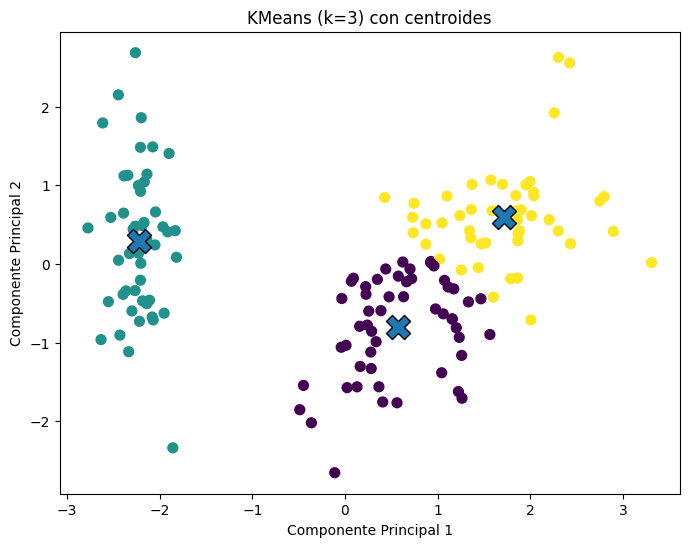

In [12]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_final = kmeans_final.fit_predict(X_iris_s)

centroides = pca.transform(
    kmeans_final.cluster_centers_
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_final,
    s=50
)

plt.scatter(
    centroides[:,0],
    centroides[:,1],
    marker="X",
    s=300,
    edgecolor="black"
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("KMeans (k=3) con centroides")

plt.savefig(
    "kmeans_clusters.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Interpretación de KMeans con centroides

Los centroides representan el centro de cada grupo identificado por KMeans. Se observa que cada centro se encuentra ubicado en una región representativa de su respectivo clúster.

La separación entre centroides refleja las diferencias existentes entre los grupos detectados. En particular, uno de los clústeres aparece claramente aislado, mientras que los otros dos presentan una proximidad mayor, aunque siguen siendo distinguibles.

La ubicación de los centroides y la distribución de las observaciones sugieren que KMeans logró capturar adecuadamente la estructura principal del dataset Iris.

In [13]:
semillas = [42, 100, 123]

for semilla in semillas:

    km = KMeans(
        n_clusters=3,
        random_state=semilla,
        n_init=10
    )

    km.fit(X_iris_s)

    print(
        f"Semilla {semilla}:",
        round(km.inertia_, 4)
    )

Semilla 42: 139.8205
Semilla 100: 140.0328
Semilla 123: 139.8205


### Estabilidad frente a distintas semillas

Se ejecutó KMeans con tres semillas diferentes (42, 100 y 123) manteniendo el mismo número de clústeres.

Las inercias obtenidas fueron muy similares entre sí, con diferencias pequeñas respecto al valor mínimo encontrado. Esto indica que el algoritmo converge a soluciones prácticamente equivalentes independientemente de la inicialización aleatoria.

Por lo tanto, puede concluirse que el agrupamiento obtenido para k=3 es estable y representa adecuadamente la estructura presente en el dataset Iris.

## **Desafío 2**

In [14]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

scaler_moons = StandardScaler()
X_moons_s = scaler_moons.fit_transform(X_moons)

print("Dimensión del dataset:", X_moons_s.shape)

Dimensión del dataset: (500, 2)


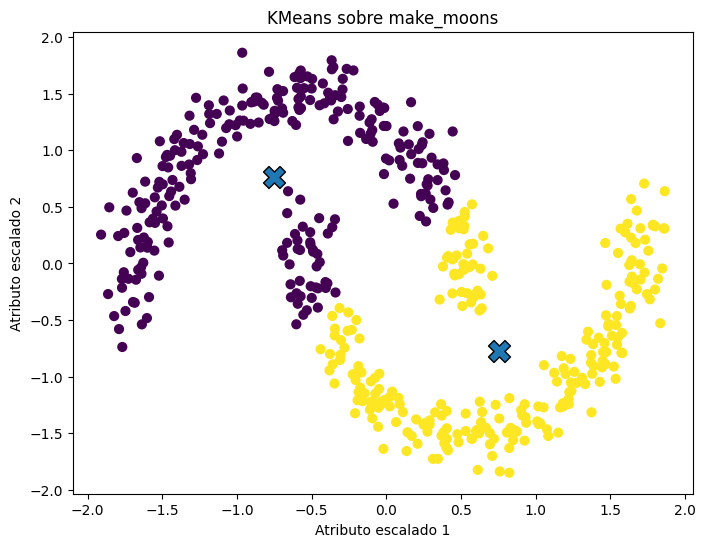

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans_moons = KMeans(
    n_clusters=2,
    init="k-means++",
    n_init=10,
    random_state=42
)

labels_kmeans = kmeans_moons.fit_predict(X_moons_s)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_moons_s[:, 0],
    X_moons_s[:, 1],
    c=labels_kmeans,
    s=40
)

plt.scatter(
    kmeans_moons.cluster_centers_[:, 0],
    kmeans_moons.cluster_centers_[:, 1],
    marker="X",
    s=250,
    edgecolor="black"
)

plt.xlabel("Atributo escalado 1")
plt.ylabel("Atributo escalado 2")
plt.title("KMeans sobre make_moons")

plt.savefig(
    "kmeans_moons.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

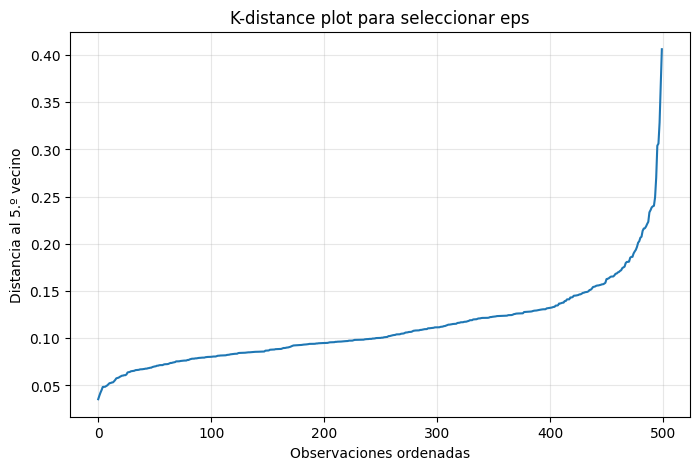

In [16]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_moons_s)

distances, indices = neighbors_fit.kneighbors(X_moons_s)

# Distancia al vecino número min_samples
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel("Observaciones ordenadas")
plt.ylabel("Distancia al 5.º vecino")
plt.title("K-distance plot para seleccionar eps")

plt.grid(alpha=0.3)

plt.savefig(
    "k_distance_plot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.17,
    min_samples=5
)

labels_dbscan = dbscan.fit_predict(
    X_moons_s
)

print(
    "Clusters encontrados:",
    len(set(labels_dbscan)) -
    (1 if -1 in labels_dbscan else 0)
)

print(
    "Ruido:",
    sum(labels_dbscan == -1)
)

Clusters encontrados: 2
Ruido: 10


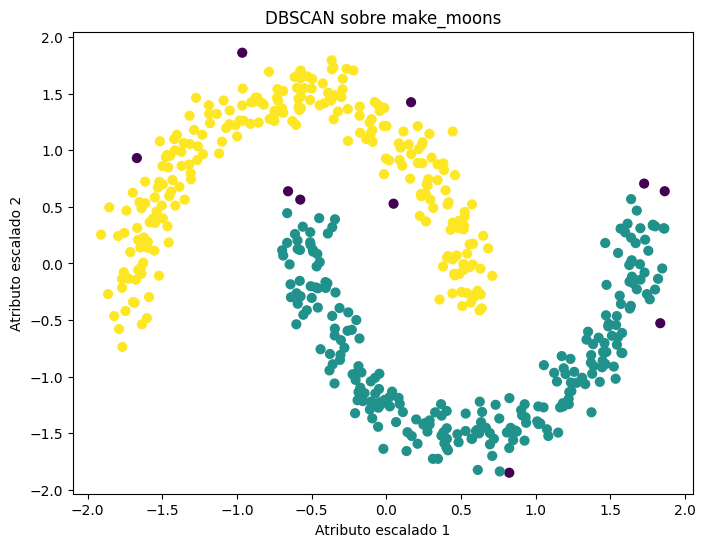

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_moons_s[:,0],
    X_moons_s[:,1],
    c=labels_dbscan,
    s=40
)

plt.xlabel("Atributo escalado 1")
plt.ylabel("Atributo escalado 2")
plt.title("DBSCAN sobre make_moons")

plt.savefig(
    "dbscan_clusters.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Comparación entre KMeans y DBSCAN

Los resultados muestran diferencias importantes entre ambos algoritmos. KMeans asume que los grupos poseen una forma aproximadamente esférica y separa las observaciones en función de la distancia a los centroides. Por esta razón, no logra representar adecuadamente la estructura curva presente en el dataset make_moons.

En contraste, DBSCAN identifica regiones densas de datos y construye los clústeres a partir de la conectividad entre observaciones vecinas. Esto le permite detectar correctamente las dos lunas sin necesidad de asumir una forma geométrica específica.

Además, DBSCAN identificó 10 observaciones como ruido, mostrando una capacidad adicional para detectar posibles valores atípicos. En este conjunto de datos, DBSCAN representa mejor la estructura natural de los datos que KMeans.

## **Desafío 3**

In [19]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()

X_wine = wine.data

scaler = StandardScaler()

X_wine_s = scaler.fit_transform(X_wine)

pca = PCA(n_components=2)

X_wine_pca = pca.fit_transform(X_wine_s)

print("Dimensión PCA:", X_wine_pca.shape)

Dimensión PCA: (178, 2)


In [20]:
from sklearn.mixture import GaussianMixture
import pandas as pd

cov_types = [
    "spherical",
    "diag",
    "tied",
    "full"
]

resultados_gmm = []

for cov in cov_types:

    gmm = GaussianMixture(
        n_components=3,
        covariance_type=cov,
        random_state=42
    )

    gmm.fit(X_wine_pca)

    resultados_gmm.append({
        "Covarianza": cov,
        "BIC": gmm.bic(X_wine_pca),
        "AIC": gmm.aic(X_wine_pca)
    })

df_gmm = pd.DataFrame(resultados_gmm)

df_gmm

,Covarianza,BIC,AIC
0,spherical,1320.788736,1285.789117
1,diag,1319.414768,1274.869798
2,tied,1323.861363,1288.861744
3,full,1313.400668,1259.310348


In [21]:
df_gmm.sort_values(
    by="BIC"
)

,Covarianza,BIC,AIC
3,full,1313.400668,1259.310348
1,diag,1319.414768,1274.869798
0,spherical,1320.788736,1285.789117
2,tied,1323.861363,1288.861744


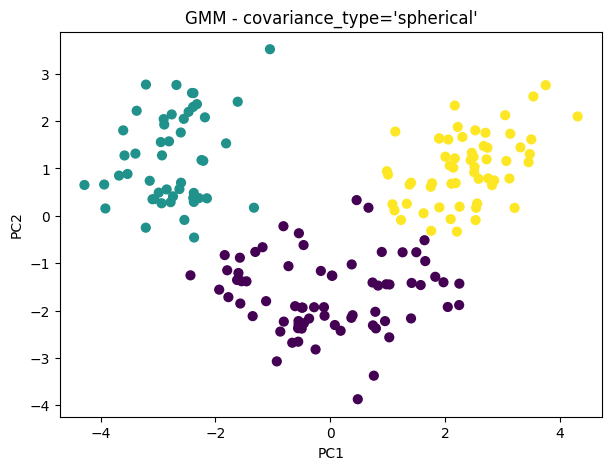

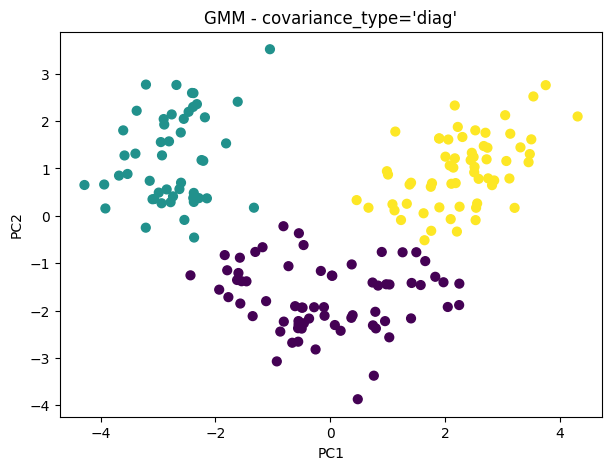

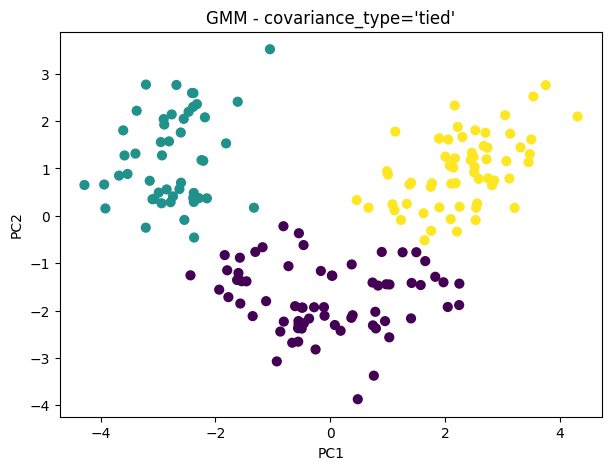

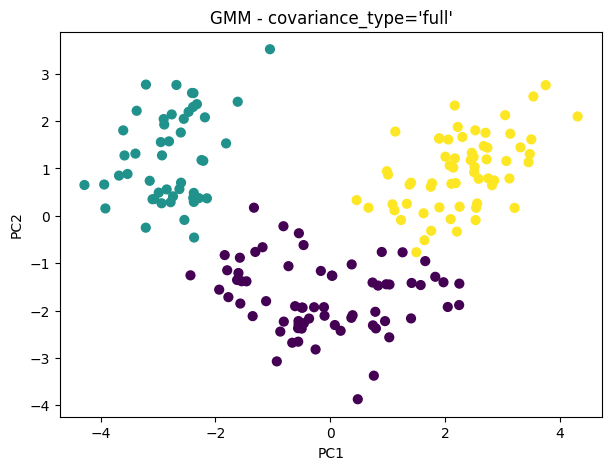

In [22]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

cov_types = [
    "spherical",
    "diag",
    "tied",
    "full"
]

for cov in cov_types:

    gmm = GaussianMixture(
        n_components=3,
        covariance_type=cov,
        random_state=42
    )

    labels = gmm.fit_predict(
        X_wine_pca
    )

    plt.figure(figsize=(7,5))

    plt.scatter(
        X_wine_pca[:,0],
        X_wine_pca[:,1],
        c=labels,
        s=40
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.title(
        f"GMM - covariance_type='{cov}'"
    )

    plt.savefig(
        f"gmm_covariances_{cov}.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

### Interpretación visual de las covarianzas

Los resultados muestran que la elección de la estructura de covarianza influye directamente en la forma de los grupos detectados por GMM.

- Spherical genera agrupaciones aproximadamente circulares.
- Diag permite diferentes dispersiones sobre cada eje, pero mantiene independencia entre variables.
- Tied obliga a todos los grupos a compartir la misma estructura de covarianza.
- Full permite que cada grupo tenga su propia orientación y forma elíptica.

Visualmente, el modelo full se adapta mejor a la distribución de las observaciones en el espacio PCA, permitiendo representar de manera más precisa las diferencias existentes entre los grupos identificados.

In [28]:
from sklearn.mixture import GaussianMixture
import pandas as pd

tipos = ["spherical", "diag", "tied", "full"]

resultados = []

for tipo in tipos:

    gmm = GaussianMixture(
        n_components=3,
        covariance_type=tipo,
        random_state=42
    )

    gmm.fit(X_wine_s[:, :2])

    resultados.append({
        "Covarianza": tipo,
        "BIC": gmm.bic(X_wine_s[:, :2]),
        "AIC": gmm.aic(X_wine_s[:, :2])
    })

df_bic_aic = pd.DataFrame(resultados)

df_bic_aic.sort_values("BIC")

,Covarianza,BIC,AIC
1,diag,927.371309,882.826339
3,full,936.933587,882.843267
0,spherical,965.216749,930.217130
2,tied,989.309254,954.309635


### Interpretación de BIC y AIC

Se compararon cuatro estructuras de covarianza para Gaussian Mixture Models: spherical, diag, tied y full, utilizando el dataset Wine proyectado a dos componentes principales mediante PCA.

El modelo con covarianza completa (full) obtuvo el menor valor de BIC (1313.40) y también el menor valor de AIC (1259.31). Dado que ambos criterios buscan evaluar la calidad del ajuste penalizando la complejidad del modelo, estos resultados indican que la estructura full proporciona la mejor representación de los datos en el espacio reducido.

La covarianza full permite que cada componente tenga su propia matriz de covarianza, capturando diferentes orientaciones, tamaños y formas elípticas de los grupos. Esta flexibilidad resulta adecuada para describir la distribución observada en los datos proyectados mediante PCA.

Los modelos spherical, diag y tied presentaron valores mayores de BIC y AIC, lo que sugiere una pérdida de capacidad para representar la variabilidad existente entre los grupos.

Por lo tanto, se selecciona el modelo GMM con covarianza full como la alternativa más apropiada para este conjunto de datos.

## **Desafío 4**

In [29]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

print("Dimensión:", X_wine_pca.shape)

Dimensión: (178, 2)


In [30]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

labels_lof = lof.fit_predict(X_wine_pca)

scores_lof = -lof.negative_outlier_factor_

print("Anomalías detectadas:",
      sum(labels_lof == -1))

Anomalías detectadas: 9


In [31]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

labels_iso = iso.fit_predict(X_wine_pca)

scores_iso = -iso.score_samples(X_wine_pca)

print("Anomalías detectadas:",
      sum(labels_iso == -1))

Anomalías detectadas: 9


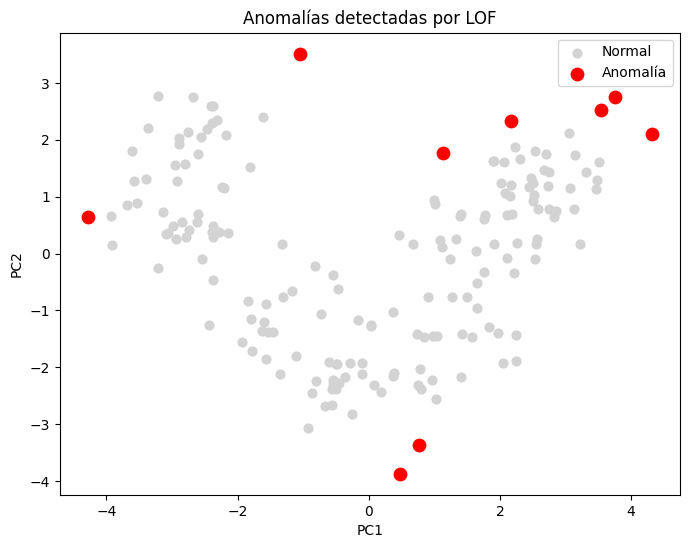

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_wine_pca[:,0],
    X_wine_pca[:,1],
    c="lightgray",
    s=40,
    label="Normal"
)

plt.scatter(
    X_wine_pca[labels_lof == -1, 0],
    X_wine_pca[labels_lof == -1, 1],
    c="red",
    s=80,
    label="Anomalía"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalías detectadas por LOF")

plt.legend()

plt.savefig(
    "outliers_lof.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

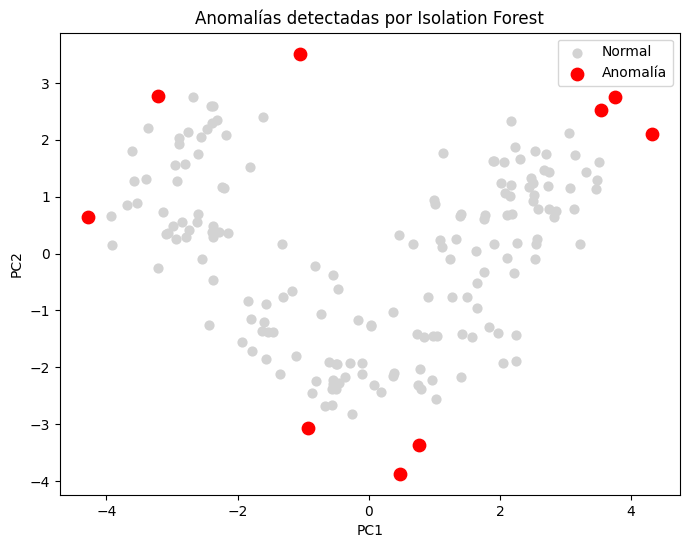

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_wine_pca[:,0],
    X_wine_pca[:,1],
    c="lightgray",
    s=40,
    label="Normal"
)

plt.scatter(
    X_wine_pca[labels_iso == -1, 0],
    X_wine_pca[labels_iso == -1, 1],
    c="red",
    s=80,
    label="Anomalía"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Anomalías detectadas por Isolation Forest")

plt.legend()

plt.savefig(
    "outliers_isolationforest.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Comparación entre LOF e Isolation Forest

Ambos métodos identificaron nueve anomalías y coincidieron en varios de los puntos más extremos del espacio PCA. Sin embargo, las anomalías detectadas no son exactamente las mismas.

LOF identifica observaciones con baja densidad local respecto a sus vecinos más cercanos, por lo que puede marcar puntos que se encuentran relativamente aislados dentro de una región poblada.

Isolation Forest, en cambio, se basa en la facilidad con que una observación puede aislarse mediante particiones aleatorias, por lo que tiende a detectar valores extremos globales.

Estas diferencias explican por qué algunos puntos fueron considerados anómalos por un método y no por el otro, aun cuando ambos identificaron la misma cantidad total de anomalías.

In [34]:
import pandas as pd
import numpy as np

top10_lof = np.argsort(scores_lof)[::-1][:10]
top10_iso = np.argsort(scores_iso)[::-1][:10]

print("Top 10 LOF:")
print(top10_lof)

print("\nTop 10 Isolation Forest:")
print(top10_iso)

Top 10 LOF:
[ 14   3 158 115  18  80  45  16 146  52]

Top 10 Isolation Forest:
[158 115  14   3  80  59 146 177  18 136]


In [35]:
top20_lof = np.argsort(scores_lof)[::-1][:20]
top20_iso = np.argsort(scores_iso)[::-1][:20]

print("Top 20 LOF:")
print(top20_lof)

print("\nTop 20 Isolation Forest:")
print(top20_iso)

Top 20 LOF:
[ 14   3 158 115  18  80  45  16 146  52  50   5  66  59  25 159   4  43
  10 123]

Top 20 Isolation Forest:
[158 115  14   3  80  59 146 177  18 136 175 155 170  66 159 173 137 116
 118  16]


In [36]:
coincidencias_10 = len(
    set(top10_lof).intersection(
        set(top10_iso)
    )
)

coincidencias_20 = len(
    set(top20_lof).intersection(
        set(top20_iso)
    )
)

print("Coincidencias Top-10:",
      coincidencias_10)

print("Coincidencias Top-20:",
      coincidencias_20)

Coincidencias Top-10: 7
Coincidencias Top-20: 11


In [37]:
df_resumen = pd.DataFrame({
    "Métrica": [
        "Coincidencias Top-10",
        "Coincidencias Top-20"
    ],
    "Valor": [
        coincidencias_10,
        coincidencias_20
    ]
})

df_resumen

,Métrica,Valor
0,Coincidencias Top-10,7
1,Coincidencias Top-20,11


### Coincidencia entre LOF e Isolation Forest

Se compararon las observaciones con mayor puntuación de anomalía obtenidas mediante LOF e Isolation Forest.

Los resultados muestran una coincidencia de 7 observaciones dentro del Top-10 y de 11 observaciones dentro del Top-20. Esto indica que ambos métodos identifican una parte importante de las observaciones atípicas, aunque no coinciden completamente en todos los casos.

Las diferencias observadas se deben a que LOF evalúa la densidad local de cada punto respecto a sus vecinos más cercanos, mientras que Isolation Forest se basa en la facilidad con que una observación puede aislarse mediante particiones aleatorias.

La coincidencia parcial encontrada sugiere que existen observaciones claramente anómalas para ambos algoritmos, mientras que otras dependen del criterio específico utilizado para medir la anomalía.

## **Desafío 5**

In [38]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

df = pd.DataFrame(
    X,
    columns=cancer.feature_names
)

print("Observaciones:", df.shape[0])
print("Variables:", df.shape[1])

df.head()

Observaciones: 569
Variables: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Descripción del dataset

Se utilizó el dataset Breast Cancer Wisconsin incluido en scikit-learn. El conjunto contiene mediciones obtenidas a partir de imágenes digitalizadas de masas mamarias, con el objetivo original de distinguir entre tumores benignos y malignos.

El dataset contiene 569 observaciones y 30 variables numéricas.

In [39]:
from sklearn.preprocessing import StandardScaler

print("Valores faltantes:")
print(df.isnull().sum().sum())

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Dimensión escalada:", X_scaled.shape)

Valores faltantes:
0
Dimensión escalada: (569, 30)


## Preprocesamiento

No se detectaron valores faltantes en el dataset. Debido a que las variables presentan diferentes escalas, se aplicó StandardScaler antes de realizar los análisis de clustering y reducción de dimensionalidad.

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "Varianza explicada acumulada:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Varianza explicada acumulada: 0.6324


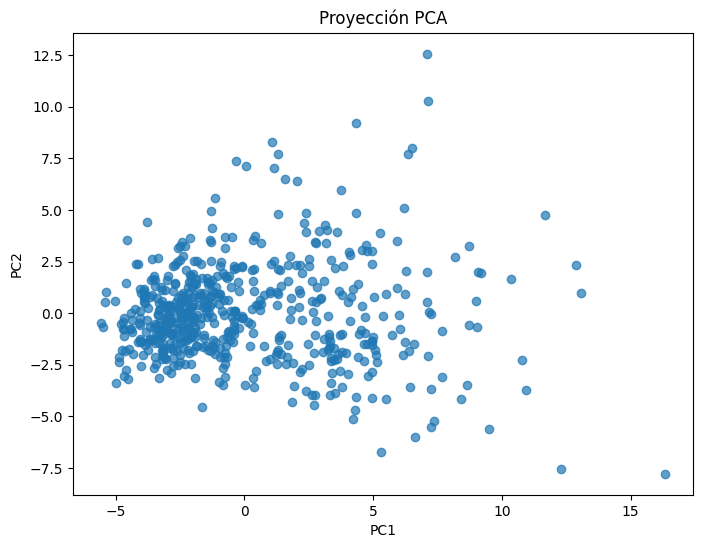

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA")

plt.savefig(
    "breast_cancer_pca.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

La proyección PCA permitió reducir las 30 variables originales a dos componentes principales, facilitando la visualización de la estructura del dataset. Se observa una concentración importante de observaciones en una región central y una dispersión progresiva hacia valores más altos de PC1. También se identifican observaciones alejadas de la nube principal, las cuales posteriormente son analizadas mediante técnicas de detección de anomalías.

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 11)

inertia = []
silhouette = []

for k in Ks:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    inertia.append(km.inertia_)

    silhouette.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

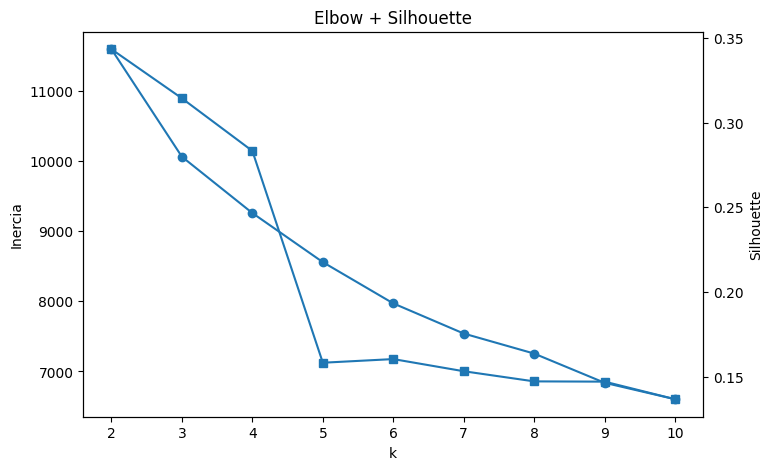

In [43]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(
    Ks,
    inertia,
    marker="o"
)

ax1.set_xlabel("k")
ax1.set_ylabel("Inercia")

ax2 = ax1.twinx()

ax2.plot(
    Ks,
    silhouette,
    marker="s"
)

ax2.set_ylabel("Silhouette")

plt.title("Elbow + Silhouette")

plt.savefig(
    "breast_cancer_elbow.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

El coeficiente de Silhouette alcanza su valor máximo para k=2, indicando la mejor separación relativa entre grupos. Asimismo, la curva de inercia presenta una reducción importante para valores pequeños de k, estabilizándose posteriormente. Considerando ambos criterios, se seleccionó k=2 para el modelo KMeans.

In [44]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)

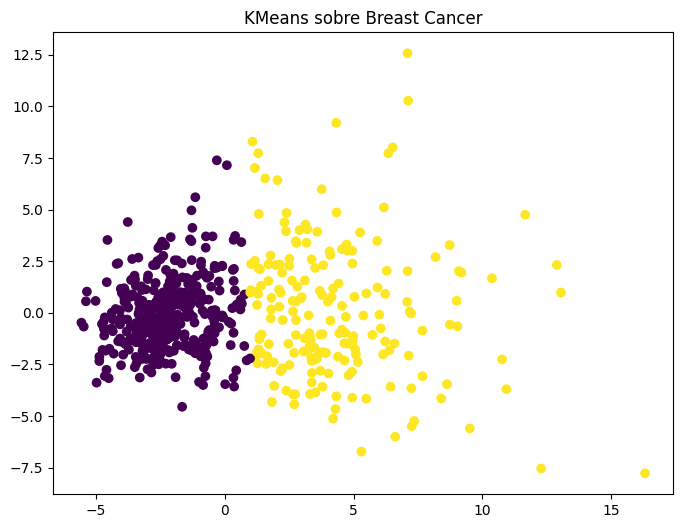

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_kmeans
)

plt.title("KMeans sobre Breast Cancer")

plt.savefig(
    "breast_cancer_kmeans.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

KMeans con k=2 identificó dos agrupaciones principales dentro del dataset. Uno de los grupos presenta una estructura más compacta, mientras que el segundo exhibe una mayor dispersión en el espacio PCA. La separación observada coincide con la sugerida por los criterios Elbow y Silhouette.

In [46]:
from sklearn.mixture import GaussianMixture

cov_types = [
    "spherical",
    "diag",
    "tied",
    "full"
]

resultados = []

for cov in cov_types:

    gmm = GaussianMixture(
        n_components=2,
        covariance_type=cov,
        random_state=42
    )

    gmm.fit(X_pca)

    resultados.append({
        "Covarianza": cov,
        "BIC": gmm.bic(X_pca),
        "AIC": gmm.aic(X_pca)
    })

pd.DataFrame(resultados).sort_values("BIC")

,Covarianza,BIC,AIC
0,spherical,5408.645841,5378.238678
3,full,5415.814667,5368.031982
1,diag,5418.529382,5379.434458
2,tied,5632.172762,5597.421718


In [47]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    contamination=0.05
)

labels_lof = lof.fit_predict(X_pca)

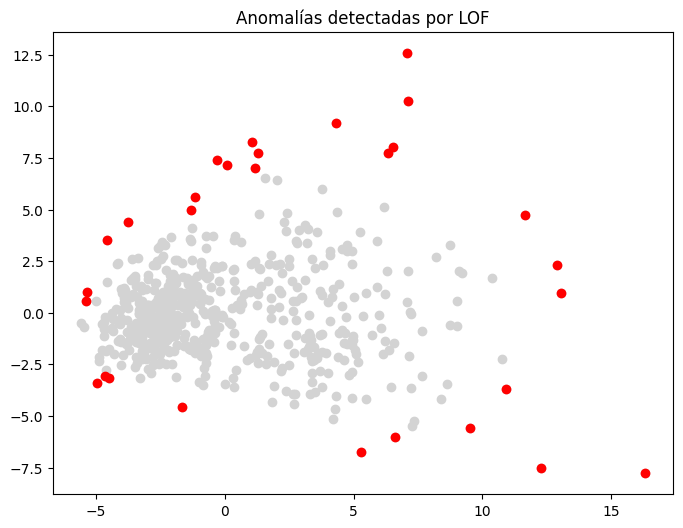

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c="lightgray"
)

plt.scatter(
    X_pca[labels_lof==-1,0],
    X_pca[labels_lof==-1,1],
    c="red"
)

plt.title("Anomalías detectadas por LOF")

plt.savefig(
    "breast_cancer_lof.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

LOF detectó observaciones con baja densidad local respecto a sus vecinos más cercanos. Las anomalías identificadas se encuentran principalmente en regiones alejadas de la concentración principal de datos, sugiriendo patrones poco frecuentes dentro del conjunto analizado.

# Conclusiones

En este trabajo se aplicaron técnicas de aprendizaje no supervisado al dataset Breast Cancer Wisconsin, compuesto por 569 observaciones y 30 variables numéricas.

Como etapa inicial se realizó un preprocesamiento mediante estandarización y posteriormente una reducción de dimensionalidad utilizando PCA, permitiendo representar la estructura general de los datos en dos componentes principales.

Para el análisis de agrupamiento se empleó KMeans. La selección del número de grupos se realizó mediante los criterios Elbow y Silhouette, obteniéndose k=2 como la alternativa más adecuada. Los resultados mostraron una separación clara entre dos agrupaciones principales en el espacio PCA.

Posteriormente se aplicó Gaussian Mixture Models (GMM) comparando distintas estructuras de covarianza. La evaluación mediante BIC y AIC indicó que el modelo spherical proporcionó el mejor equilibrio entre calidad de ajuste y complejidad.

Finalmente se utilizó Local Outlier Factor (LOF) para detectar observaciones atípicas. Las anomalías identificadas se localizaron principalmente en regiones alejadas de la concentración principal de datos, evidenciando patrones poco frecuentes dentro del conjunto analizado.

En conjunto, los métodos aplicados permitieron explorar la estructura interna del dataset, identificar agrupaciones relevantes y detectar posibles observaciones anómalas, demostrando la utilidad de las técnicas de aprendizaje no supervisado para el análisis exploratorio de datos.